# 02. Feature Engineering, Statistical Validation & Preprocessing

**Objective**: Transform raw exploratory insights into informative domain features, resolve division edge-cases and mathematical outliers, encode categorical attributes safely with strict index alignment, perform statistical feature validation ($p$-value hypothesis testing), and export a clean model-ready dataset.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from collections import Counter

## 1. Data Cleaning & Administrative Feature Pruning

In [2]:
df = pd.read_csv("data/Churn_Modelling.csv")
df1 = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Domain-Driven Feature Engineering

### Feature 1: Zero Balance Indicator

In [3]:
df1[df1['Balance'] == 0].shape

(3617, 11)

In [4]:
df1['ZeroBalance'] = (df1['Balance'] == 0)

In [5]:
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,True
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,False
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,False
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,True
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,False


In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
 11  ZeroBalance      10000 non-null  bool   
dtypes: bool(1), float64(2), int64(7), object(2)
memory usage: 869.3+ KB


In [7]:
# Convert boolean flag into integer representation
df1['ZeroBalance'] = df1['ZeroBalance'].astype(int)
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0


### Feature 2: Exploratory Age Group Segmentation & Elder Loyalty Analysis

In [8]:
print(df1['Age'].describe())

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64


In [9]:
print(df1['Age'].quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

0.01    21.0
0.05    25.0
0.50    37.0
0.95    60.0
0.99    72.0
Name: Age, dtype: float64


In [10]:
df1['AgeGroup'] = pd.cut(df1['Age'], bins=[0, 30, 45, 60, 100], labels=['Young', 'MiddleAged', 'Senior', 'Elder'])
print(df1['AgeGroup'].value_counts(dropna=False))

AgeGroup
MiddleAged    5921
Young         1968
Senior        1647
Elder          464
Name: count, dtype: int64


In [11]:
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,AgeGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,MiddleAged
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,MiddleAged
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,MiddleAged
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1,MiddleAged
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,MiddleAged


In [12]:
df1.groupby('AgeGroup')['Exited'].mean()

C:\Users\tejas\AppData\Local\Temp\ipykernel_6672\4134172352.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('AgeGroup')['Exited'].mean()


AgeGroup
Young         0.075203
MiddleAged    0.157406
Senior        0.511233
Elder         0.247845
Name: Exited, dtype: float64

In [13]:
# Deep dive: Why does Elder churn drop to 24.7% while Senior churn peaks at 51.1%?
# Checking churn rates among older customers (> 60) by member engagement status:
df1[df1['Age'] > 60].groupby('IsActiveMember')['Exited'].mean()

IsActiveMember
0    0.820225
1    0.112000
Name: Exited, dtype: float64

In [14]:
df1.groupby('AgeGroup')['Exited'].value_counts()

C:\Users\tejas\AppData\Local\Temp\ipykernel_6672\3047100963.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('AgeGroup')['Exited'].value_counts()


AgeGroup    Exited
Young       0         1820
            1          148
MiddleAged  0         4989
            1          932
Senior      1          842
            0          805
Elder       0          349
            1          115
Name: count, dtype: int64

In [15]:
df1.groupby('AgeGroup')['Exited'].sum()

C:\Users\tejas\AppData\Local\Temp\ipykernel_6672\3576911391.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('AgeGroup')['Exited'].sum()


AgeGroup
Young         148
MiddleAged    932
Senior        842
Elder         115
Name: Exited, dtype: int64

In [16]:
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,AgeGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,MiddleAged
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,MiddleAged
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,MiddleAged
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1,MiddleAged
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,MiddleAged


### Feature 3: Product Activity Interaction

In [17]:
pd.crosstab(df1['NumOfProducts'], df1['IsActiveMember'])

IsActiveMember,0,1
NumOfProducts,,
1,2521,2563
2,2144,2446
3,153,113
4,31,29


In [18]:
df1['ProductActivity'] = df1['NumOfProducts'] * df1['IsActiveMember']

In [19]:
df1.groupby('ProductActivity')['Exited'].sum()

ProductActivity
0    1302
1     485
2     136
3      85
4      29
Name: Exited, dtype: int64

In [20]:
df1.groupby('ProductActivity')['Exited'].value_counts()

ProductActivity  Exited
0                0         3547
                 1         1302
1                0         2078
                 1          485
2                0         2310
                 1          136
3                1           85
                 0           28
4                1           29
Name: count, dtype: int64

In [21]:
df1.groupby('ProductActivity')['Exited'].mean()

ProductActivity
0    0.268509
1    0.189231
2    0.055601
3    0.752212
4    1.000000
Name: Exited, dtype: float64

In [22]:
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,AgeGroup,ProductActivity
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,MiddleAged,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,MiddleAged,1
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,MiddleAged,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1,MiddleAged,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,MiddleAged,1


### Feature 4: Balance-to-Salary Ratio & Outlier Capping

In [23]:
(df1['EstimatedSalary'] == 0).sum()

0

In [24]:
(df1['Balance'] == 0).sum()

3617

In [25]:
# Defensive coding (+ 1) protecting against potential division-by-zero in streaming data
df1['BalanceSalaryRatio'] = df1['Balance'] / (df1['EstimatedSalary'] + 1)
print(df1['BalanceSalaryRatio'].describe())

count    10000.000000
mean         3.790150
std        100.055758
min          0.000000
25%          0.000000
50%          0.746998
75%          1.514002
max       9770.883148
Name: BalanceSalaryRatio, dtype: float64


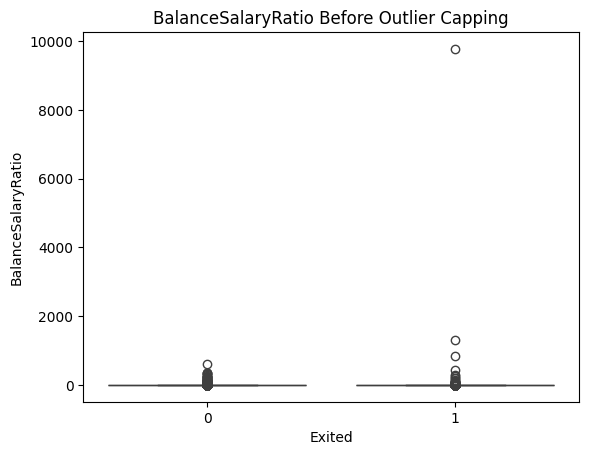

In [26]:
sns.boxplot(x="Exited", y="BalanceSalaryRatio", data=df1)
plt.title("BalanceSalaryRatio Before Outlier Capping")
plt.show()

In [27]:
print((df1['BalanceSalaryRatio'] == 0).sum())

3617


In [28]:
cap_99 = df1['BalanceSalaryRatio'].quantile(0.99)
print(f"99th percentile cap threshold: {cap_99:.4f}")

99th percentile cap threshold: 35.4762


In [29]:
df1['BalanceSalaryRatio'] = df1['BalanceSalaryRatio'].clip(upper=cap_99)

In [30]:
df1['BalanceSalaryRatio'].describe()

count    10000.000000
mean         1.865257
std          4.668888
min          0.000000
25%          0.000000
50%          0.746998
75%          1.514002
max         35.476218
Name: BalanceSalaryRatio, dtype: float64

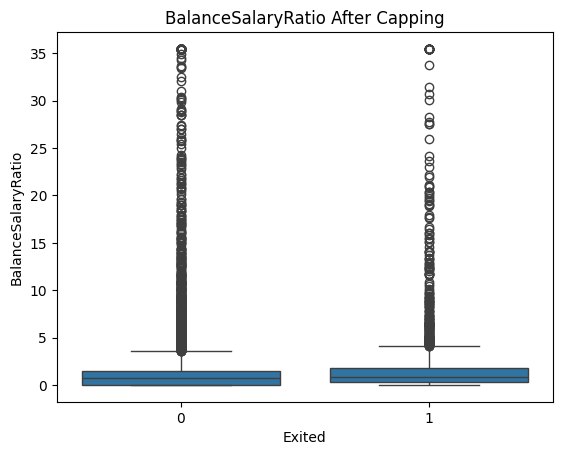

In [31]:
sns.boxplot(x="Exited", y="BalanceSalaryRatio", data=df1)
plt.title("BalanceSalaryRatio After Capping")
plt.show()

### Feature 5: Tenure-to-Age Ratio (Zero-Tenure Edge Case Smoothing)

In [32]:
# Verify tenure distribution and edge cases before ratio math
print("Tenure null count:", df1["Tenure"].isnull().sum())
print("Customers with Tenure == 0:", (df1["Tenure"] == 0).sum())
print("Customers with Age == 0:", (df1["Age"] == 0).sum())

Tenure null count: 0
Customers with Tenure == 0: 413
Customers with Age == 0: 0


In [33]:
df1[df1['Tenure'] == 0].head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,AgeGroup,ProductActivity,BalanceSalaryRatio
29,411,France,Male,29,0,59697.17,2,1,1,53483.21,0,0,Young,2,1.116164
35,475,France,Female,45,0,134264.04,1,1,0,27822.99,1,0,MiddleAged,0,4.825478
57,725,Germany,Male,19,0,75888.20,1,0,0,45613.75,0,0,Young,0,1.663677
72,657,Spain,Female,37,0,163607.18,1,0,1,44203.55,0,0,MiddleAged,1,3.701139
127,625,Germany,Male,56,0,148507.24,1,1,0,46824.08,1,0,Senior,0,3.171532


In [34]:
# Apply +0.5 additive smoothing to protect zero-tenure rows from losing predictive ranking signal
df1['TenureAgeRatio'] = (df1['Tenure'] + 0.5) / df1['Age']
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,AgeGroup,ProductActivity,BalanceSalaryRatio,TenureAgeRatio
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,MiddleAged,1,0.000000,0.059524
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,MiddleAged,1,0.744670,0.036585
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,MiddleAged,0,1.401362,0.202381
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1,MiddleAged,0,0.000000,0.038462
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,MiddleAged,1,1.587035,0.058140


In [35]:
df1.shape

(10000, 16)

## 3. Categorical Encoding & Index Alignment

In [36]:
# Binary encoding for Gender
le = LabelEncoder()
df1['Gender_Encoded'] = le.fit_transform(df1['Gender'])

In [37]:
# One-Hot Encoding for multi-class categorical attribute (drop='first' avoids multicollinearity)
encoder = OneHotEncoder(drop='first', sparse_output=False)

# CRITICAL ENGINEERING SAFEGUARD: Passing index=df1.index guarantees strict row alignment during concatenation
geo_encoded = pd.DataFrame(
    encoder.fit_transform(df1[['Geography']]),
    columns=encoder.get_feature_names_out(),
    index=df1.index
)
print("Target distributions check:", Counter(df1['Exited']))
geo_encoded.head()

Target distributions check: Counter({0: 7963, 1: 2037})


,Geography_Germany,Geography_Spain
0,0.0,0.0
1,0.0,1.0
2,0.0,0.0
3,0.0,0.0
4,0.0,1.0


In [38]:
df1 = pd.concat([df1, geo_encoded], axis=1)
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,AgeGroup,ProductActivity,BalanceSalaryRatio,TenureAgeRatio,Gender_Encoded,Geography_Germany,Geography_Spain
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,MiddleAged,1,0.000000,0.059524,0,0.0,0.0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,MiddleAged,1,0.744670,0.036585,0,0.0,1.0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,MiddleAged,0,1.401362,0.202381,0,0.0,0.0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1,MiddleAged,0,0.000000,0.038462,0,0.0,0.0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,MiddleAged,1,1.587035,0.058140,0,0.0,1.0


In [39]:
# Drop raw text features and temporary exploratory segmentation column
df1 = df1.drop(columns=["Geography", "Gender", "AgeGroup"])
df1.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,ProductActivity,BalanceSalaryRatio,TenureAgeRatio,Gender_Encoded,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,1,1,0.000000,0.059524,0,0.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0.744670,0.036585,0,0.0,1.0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,1.401362,0.202381,0,0.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0.000000,0.038462,0,0.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,1.587035,0.058140,0,0.0,1.0


In [40]:
df1.dtypes

CreditScore             int64
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
ZeroBalance             int32
ProductActivity         int64
BalanceSalaryRatio    float64
TenureAgeRatio        float64
Gender_Encoded          int32
Geography_Germany     float64
Geography_Spain       float64
dtype: object

## 4. Statistical Feature Selection & Collinearity Audit

In [41]:
corr_matrix = df1.corr()

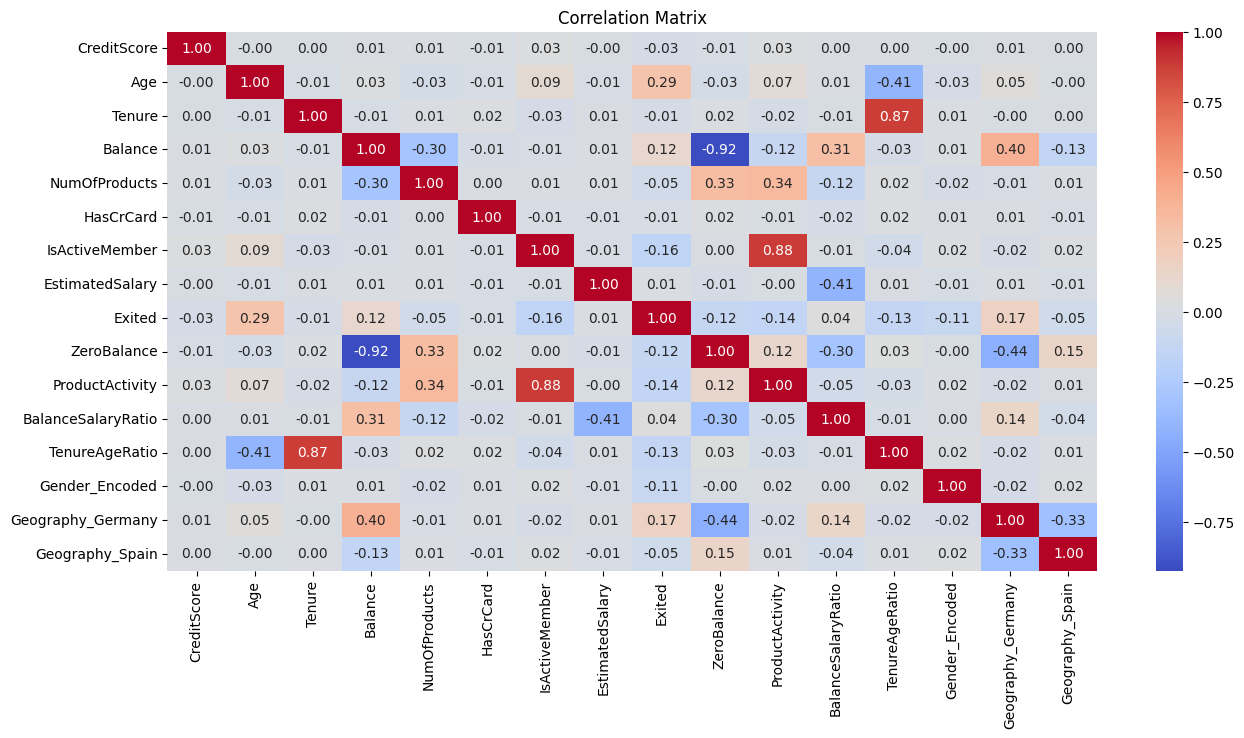

In [42]:
plt.figure(figsize=(15, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [43]:
corr_with_target = corr_matrix['Exited'].drop('Exited').sort_values(ascending=False)
print(corr_with_target)

Age                   0.285323
Geography_Germany     0.173488
Balance               0.118533
BalanceSalaryRatio    0.041538
EstimatedSalary       0.012097
HasCrCard            -0.007138
Tenure               -0.014001
CreditScore          -0.027094
NumOfProducts        -0.047820
Geography_Spain      -0.052667
Gender_Encoded       -0.106512
ZeroBalance          -0.122357
TenureAgeRatio       -0.130629
ProductActivity      -0.137902
IsActiveMember       -0.156128
Name: Exited, dtype: float64


In [44]:
# Point-Biserial correlation hypothesis testing against binary target Exited
# Any feature with p > 0.05 has NO statistically significant relationship with churn
for col in df1.drop(columns=['Exited']).columns:
    corr, pval = stats.pointbiserialr(df1[col], df1['Exited'])
    print(f"{col:20} -> r = {corr:8.4f}, p-value = {pval:.4f}")

CreditScore          -> r =  -0.0271, p-value = 0.0067
Age                  -> r =   0.2853, p-value = 0.0000
Tenure               -> r =  -0.0140, p-value = 0.1615
Balance              -> r =   0.1185, p-value = 0.0000
NumOfProducts        -> r =  -0.0478, p-value = 0.0000
HasCrCard            -> r =  -0.0071, p-value = 0.4754
IsActiveMember       -> r =  -0.1561, p-value = 0.0000
EstimatedSalary      -> r =   0.0121, p-value = 0.2264
ZeroBalance          -> r =  -0.1224, p-value = 0.0000
ProductActivity      -> r =  -0.1379, p-value = 0.0000
BalanceSalaryRatio   -> r =   0.0415, p-value = 0.0000
TenureAgeRatio       -> r =  -0.1306, p-value = 0.0000
Gender_Encoded       -> r =  -0.1065, p-value = 0.0000
Geography_Germany    -> r =   0.1735, p-value = 0.0000
Geography_Spain      -> r =  -0.0527, p-value = 0.0000


### Statistical & Domain Feature Pruning

In [45]:
# Check penetration rate of HasCrCard before pruning
df1["HasCrCard"].mean()

0.7055

In [46]:
# Confident drop: HasCrCard (p=0.4754, redundant across 70.5% of bank), Tenure (p=0.1615, replaced by TenureAgeRatio), EstimatedSalary (p=0.2264, replaced by BalanceSalaryRatio)
df1 = df1.drop(columns=["HasCrCard", "Tenure", "EstimatedSalary"])
df1.head()

,CreditScore,Age,Balance,NumOfProducts,IsActiveMember,Exited,ZeroBalance,ProductActivity,BalanceSalaryRatio,TenureAgeRatio,Gender_Encoded,Geography_Germany,Geography_Spain
0,619,42,0.00,1,1,1,1,1,0.000000,0.059524,0,0.0,0.0
1,608,41,83807.86,1,1,0,0,1,0.744670,0.036585,0,0.0,1.0
2,502,42,159660.80,3,0,1,0,0,1.401362,0.202381,0,0.0,0.0
3,699,39,0.00,2,0,0,1,0,0.000000,0.038462,0,0.0,0.0
4,850,43,125510.82,1,1,0,0,1,1.587035,0.058140,0,0.0,1.0


In [47]:
df1.shape

(10000, 13)

## 5. Serialization & Data Pipeline Hand-off

In [48]:
# Export final cleaned 13-column feature matrix for modeling execution in Notebook 03
df1.to_csv("data/churn_cleaned.csv", index=False)
print("Successfully exported cleaned dataset to data/churn_cleaned.csv")

Successfully exported cleaned dataset to data/churn_cleaned.csv
